<a href="https://colab.research.google.com/github/knyazevaanna16-arch/algorithmization_tsib_251_12/blob/main/lw_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ЗАДАНИЕ 1: ГРАФЫ

Матрица смежности:
[0, 1, 0, 0, 0, 0]
[1, 0, 1, 0, 0, 0]
[0, 1, 0, 1, 1, 0]
[0, 0, 1, 0, 1, 0]
[0, 0, 1, 1, 0, 1]
[0, 0, 0, 0, 1, 0]

Матрица инцидентности:
[1, 0, 0, 0, 0, 0]
[1, 1, 0, 0, 0, 0]
[0, 1, 1, 0, 0, 1]
[0, 0, 1, 1, 0, 0]
[0, 0, 0, 1, 1, 1]
[0, 0, 0, 0, 1, 0]

Компоненты связности: [[1, 2, 3, 4, 5, 6]]

ЗАДАНИЕ 2: ДЕРЕВО (BST)

Вставляем элементы: [26, 15, 32, 12, 18, 28, 40]


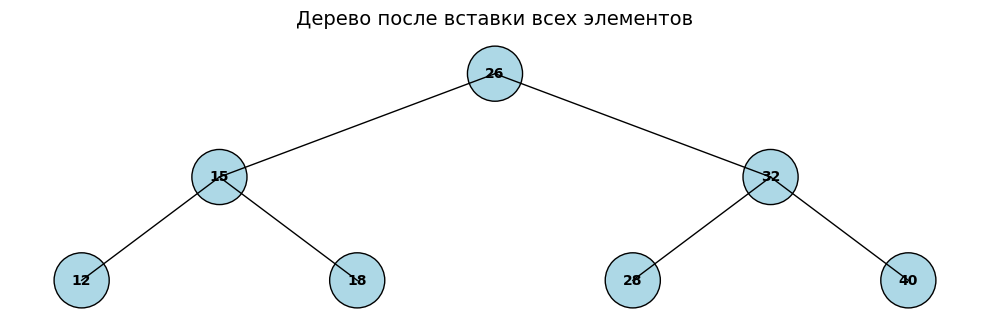


Поиск элемента 15: Найден
Удаляем элемент 26...


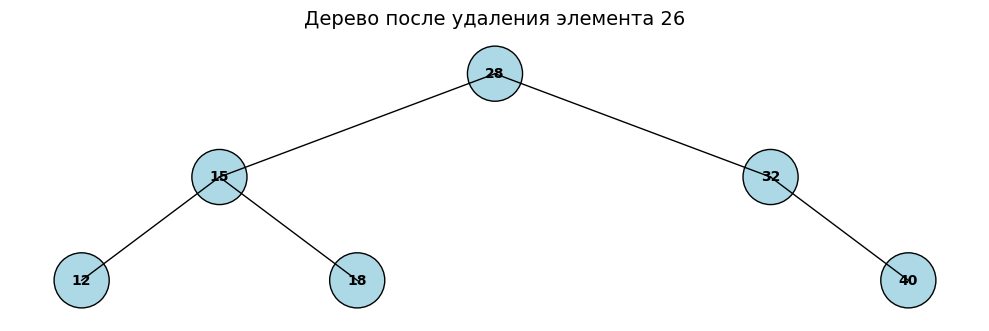


ЗАДАНИЕ 3: HEAP SORT
Исходный массив: [26, 15, 32, 12, 18, 28, 40]
Отсортированный массив: [12, 15, 18, 26, 28, 32, 40]


In [8]:
# Задание task_02_12.
# Дано: 6 вершин: (1,2), (2,3), (3,4), (4,5), (5,6), (3,5)
#       дерево: {26, 15, 32, 12, 18, 28, 40}
#       Найти: 15,
#       Уд.: 26

# Выполнил: Князева А. П.
# Группа: ЦИБ-251

# ==========================================
# БИБЛИОТЕКИ
# ==========================================
import matplotlib.pyplot as plt  # Импорт библиотеки для построения графиков и визуализации [O(1)]
import matplotlib.patches as mpatches  # Импорт модуля для рисования фигур (кругов, прямоугольников) [O(1)]

# ==========================================
# ЧАСТЬ 1: ГРАФЫ
# ==========================================

def create_adjacency_matrix(vertices_count, edges):
    """Создает матрицу смежности"""
    # Создаем квадратную матрицу N x N, заполненную нулями [O(V^2)]
    # N - количество вершин
    matrix = [[0] * vertices_count for _ in range(vertices_count)] # O(V^2)

    # Проходим по списку всех ребер графа [Цикл выполняется E раз]
    for u, v in edges: # O(E) итераций
        # В матрице смежности ставим 1 на пересечении строки u и столбца v [O(1)]
        # Вычитаем 1, так как вершины нумеруются с 1, а индексы списка в Python с 0
        matrix[u - 1][v - 1] = 1 # O(1)

        # Так как граф неориентированный (ребро A-B равно B-A),  [O(1)]
        # ставим 1 и в симметричную ячейку
        matrix[v - 1][u - 1] = 1 # O(1)

    # Возвращаем готовую матрицу [O(1)]
    return matrix

def create_incidence_matrix(vertices_count, edges):
    """Создает матрицу инцидентности"""
    # Узнаем количество ребер для определения ширины матрицы [O(1)]
    edges_count = len(edges) # O(1)

    # Создаем матрицу размером V (вершины) x E (ребра), заполненную нулями [O(V * E)]
    matrix = [[0] * edges_count for _ in range(vertices_count)] # O(V * E)

    # Перебираем ребра с их индексом (i - номер столбца в матрице инцидентности) [Цикл E раз]
    for i, (u, v) in enumerate(edges): # O(E) итераций
        # Ставим 1 в строке вершины u для текущего ребра i [O(1)]
        matrix[u - 1][i] = 1 # O(1)
        # Ставим 1 в строке вершины v для текущего ребра i [O(1)]
        matrix[v - 1][i] = 1 # O(1)

    # Возвращаем готовую матрицу [O(1)]
    return matrix

def find_connected_components(vertices_count, edges):
    """Ищет компоненты связности через алгоритм DFS (поиск в глубину)"""

    # Создаем список смежности: для каждой вершины храним список её соседей [O(V)]
    # Это нужно для быстрого доступа при обходе графа
    adj = [[] for _ in range(vertices_count)] # O(V)

    # Заполняем список смежности на основе списка ребер [Цикл E раз]
    for u, v in edges: # O(E) итераций
        # Добавляем v в список соседей u (учитывая сдвиг индекса на -1) [O(1)]
        adj[u - 1].append(v - 1) # O(1) amortized
        # Добавляем u в список соседей v (граф неориентированный) [O(1)]
        adj[v - 1].append(u - 1) # O(1) amortized

    # Массив для отслеживания посещенных вершин (изначально все False) [O(V)]
    visited = [False] * vertices_count # O(V)

    # Список для хранения найденных компонент связности [O(1)]
    components = [] # O(1)

    # Внутренняя рекурсивная функция для обхода в глубину
    def dfs(node, component):
        # Помечаем текущую вершину как посещенную [O(1)]
        visited[node] = True # O(1)
        # Добавляем номер вершины (возвращаем +1, чтобы были числа 1..N) в текущую компоненту [O(1)]
        component.append(node + 1) # O(1)

        # Проходим по всем соседям текущей вершины [Суммарно по всем вызовам DFS: O(E)]
        for neighbor in adj[node]: # Зависит от степени вершины
            # Если сосед еще не был посещен [O(1)]
            if not visited[neighbor]: # O(1)
                # Рекурсивно запускаем DFS для этого соседа [Рекурсия]
                dfs(neighbor, component) # Рекурсивный вызов

    # Основной цикл: проверяем каждую вершину от 0 до N-1 [Цикл V раз]
    for i in range(vertices_count): # O(V) итераций
        # Если вершина еще не посещена, значит, она начинает новую компоненту связности [O(1)]
        if not visited[i]: # O(1)
            new_comp = [] # Создаем пустой список для новой компоненты [O(1)]
            dfs(i, new_comp) # Запускаем обход из этой вершины [Суммарно O(V+E) за все запуски]
            components.append(new_comp) # Сохраняем найденную компоненту в общий список [O(1)]

    # Возвращаем список всех компонент связности [O(1)]
    return components

# ==========================================
# ЧАСТЬ 2: ДЕРЕВО (BST) + ВИЗУАЛИЗАЦИЯ
# ==========================================

class Node:
    """Класс, описывающий один узел дерева"""
    def __init__(self, key):
        self.key = key      # Значение, хранящееся в узле [O(1)]
        self.left = None    # Ссылка на левого потомка (изначально нет) [O(1)]
        self.right = None   # Ссылка на правого потомка (изначально нет) [O(1)]

class BinarySearchTree:
    """Класс, описывающий бинарное дерево поиска и операции с ним"""
    def __init__(self):
        self.root = None  # Инициализируем дерево как пустое (корня нет) [O(1)]

    def insert(self, key):
        """Публичный метод для вставки нового элемента"""
        if self.root is None:
            # Если дерево пусто, новый элемент становится корнем [O(1)]
            self.root = Node(key) # O(1)
        else:
            # Иначе запускаем рекурсивную вставку от корня [O(H)]
            self._insert_recursive(self.root, key) # O(H)

    def _insert_recursive(self, node, key):
        """Рекурсивный помощник для вставки"""
        if key < node.key:
            # Если ключ меньше текущего узла, идем влево [O(1)]
            if node.left is None:
                # Если слева пусто, создаем новый узел [O(1)]
                node.left = Node(key) # O(1)
            else:
                # Иначе спускаемся дальше влево [Рекурсия]
                self._insert_recursive(node.left, key) # Рекурсивный вызов
        elif key > node.key:
            # Если ключ больше текущего узла, идем вправо [O(1)]
            if node.right is None:
                # Если справа пусто, создаем новый узел [O(1)]
                node.right = Node(key) # O(1)
            else:
                # Иначе спускаемся дальше вправо [Рекурсия]
                self._insert_recursive(node.right, key) # Рекурсивный вызов
        # Если key == node.key, ничего не делаем (дубликаты обычно не вставляются) [O(1)]

    def search(self, key):
        """Публичный метод для поиска элемента"""
        return self._search_recursive(self.root, key) # O(H)

    def _search_recursive(self, node, key):
        """Рекурсивный помощник для поиска"""
        if node is None:
            # Если дошли до пустого места, элемент не найден [O(1)]
            return False
        if node.key == key:
            # Если значение совпало, элемент найден [O(1)]
            return True
        elif key < node.key:
            # Если искомое меньше, ищем в левом поддереве [Рекурсия]
            return self._search_recursive(node.left, key) # Рекурсивный вызов
        else:
            # Если искомое больше, ищем в правом поддереве [Рекурсия]
            return self._search_recursive(node.right, key) # Рекурсивный вызов

    def delete(self, key):
        """Публичный метод для удаления элемента"""
        # Обновляем корень дерева результатом рекурсивного удаления [O(H)]
        self.root = self._delete_recursive(self.root, key) # O(H)

    def _delete_recursive(self, node, key):
        """Рекурсивный помощник для удаления"""
        if node is None:
            # Если узел не найден, возвращаем None [O(1)]
            return node

        if key < node.key:
            # Если ключ меньше, ищем удаляемый узел в левом поддереве [Рекурсия]
            node.left = self._delete_recursive(node.left, key) # Рекурсивный вызов
        elif key > node.key:
            # Если ключ больше, ищем удаляемый узел в правом поддереве [Рекурсия]
            node.right = self._delete_recursive(node.right, key) # Рекурсивный вызов
        else:
            # === Узел найден (key == node.key) ===

            # Случай 1: У узла нет левого ребенка или он один [O(1)]
            if node.left is None:
                # Заменяем узел его правым ребенком (или None, если правого тоже нет) [O(1)]
                return node.right
            # Случай 2: У узла нет правого ребенка [O(1)]
            elif node.right is None:
                # Заменяем узел его левым ребенком [O(1)]
                return node.left

            # Случай 3: У узла два ребенка
            # Находим наименьший элемент в правом поддереве (преемника) [O(H)]
            temp = self._find_min(node.right) # O(H)
            # Копируем значение преемника в текущий узел [O(1)]
            node.key = temp.key # O(1)
            # Рекурсивно удаляем преемника из правого поддерева
            # (там он уже будет иметь максимум одного ребенка) [Рекурсия]
            node.right = self._delete_recursive(node.right, temp.key) # Рекурсивный вызов

        # Возвращаем (возможно, обновленный) узел [O(1)]
        return node

    def _find_min(self, node):
        """Поиск узла с минимальным ключом в поддереве"""
        current = node
        # Минимальный элемент всегда самый левый [Цикл до H шагов]
        while current.left is not None: # O(H) в худшем случае
            current = current.left # O(1)
        return current

    def visualize(self, title="Binary Search Tree"):
        """
        Метод для визуализации дерева с помощью matplotlib.
        Рисует узлы и связи между ними.
        """
        if self.root is None:
            print("Дерево пусто")
            return

        # Создаем фигуру и оси для графика [O(1)]
        fig, ax = plt.subplots(figsize=(10, 6)) # O(1)

        # Вложенная рекурсивная функция для отрисовки
        # node - текущий узел, x,y - координаты, dx - горизонтальный отступ для детей
        def draw_node(node, x, y, dx):
            if node is None:
                return

            # Рисуем круг (узл) в координатах x, y радиусом 0.4 [O(1)]
            circle = plt.Circle((x, y), 0.4, color='lightblue', ec='black') # O(1)
            ax.add_patch(circle) # O(1)

            # Пишем значение ключа внутри круга [O(1)]
            ax.text(x, y, str(node.key), ha='center', va='center', fontsize=10, fontweight='bold') # O(1)

            # Если есть левый ребенок
            if node.left:
                # Рисуем линию от родителя к левому ребенку [O(1)]
                ax.plot([x, x - dx], [y, y - 1.5], 'k-', lw=1) # O(1)
                # Рекурсивно рисуем левого ребенка
                # Сдвигаемся влево (x - dx) и вниз (y - 1.5)
                # Уменьшаем отступ dx вдвое для следующего уровня, чтобы ветки не слипались
                draw_node(node.left, x - dx, y - 1.5, dx / 2) # Рекурсия

            # Если есть правый ребенок
            if node.right:
                # Рисуем линию от родителя к правому ребенку [O(1)]
                ax.plot([x, x + dx], [y, y - 1.5], 'k-', lw=1) # O(1)
                # Рекурсивно рисуем правого ребенка
                # Сдвигаемся вправо (x + dx) и вниз (y - 1.5)
                draw_node(node.right, x + dx, y - 1.5, dx / 2) # Рекурсия

        # Запускаем отрисовку с корня
        # Начальные координаты: x=0, y=0, начальный размах dx=4
        draw_node(self.root, 0, 0, 4) # Посещает каждый узел 1 раз: O(N)

        # Настройки внешнего вида графика
        ax.set_aspect('equal') # Сохраняем пропорции, чтобы круги были круглыми [O(1)]
        ax.axis('off')         # Отключаем отображение осей координат [O(1)]
        plt.title(title, fontsize=14) # Устанавливаем заголовок [O(1)]
        plt.tight_layout()     # Автоматическая настройка отступов [O(1)]
        plt.show()             # Показываем график [Зависит от рендерера, обычно быстро]

# ==========================================
# ЧАСТЬ 3: HEAP SORT (ПИРАМИДАЛЬНАЯ СОРТИРОВКА)
# ==========================================

def heapify(arr, n, i):
    """
    Функция для поддержания свойства кучи (Max-Heap).
    arr - массив, n - размер кучи, i - индекс корня поддерева.
    """
    largest = i       # Инициализируем наибольший элемент как корень [O(1)]
    left = 2 * i + 1  # Индекс левого ребенка [O(1)]
    right = 2 * i + 2 # Индекс правого ребенка [O(1)]

    # Если левый ребенок существует и больше текущего наибольшего [O(1)]
    if left < n and arr[left] > arr[largest]: # O(1)
        largest = left # O(1)

    # Если правый ребенок существует и больше текущего наибольшего [O(1)]
    if right < n and arr[right] > arr[largest]: # O(1)
        largest = right # O(1)

    # Если наибольший элемент не корень [O(1)]
    if largest != i: # O(1)
        # Меняем местами корень и наибольший элемент [O(1)]
        arr[i], arr[largest] = arr[largest], arr[i] # O(1)
        # Рекурсивно вызываем heapify для затронутого поддерева [Рекурсия глубины log N]
        heapify(arr, n, largest) # Рекурсивный вызов

def heap_sort(arr):
    """Основная функция сортировки"""
    n = len(arr) # O(1)

    # Этап 1: Построение кучи (переупорядочивание массива)
    # Проходим от последнего несолистового узла к корню [Цикл ~N/2 раз]
    for i in range(n // 2 - 1, -1, -1): # O(N) итераций
        heapify(arr, n, i) # O(log N) в худшем случае для одного вызова

    # Этап 2: Извлечение элементов из кучи по одному [Цикл N-1 раз]
    for i in range(n - 1, 0, -1): # O(N) итераций
        # Перемещаем текущий максимум (корень) в конец массива [O(1)]
        arr[0], arr[i] = arr[i], arr[0] # O(1)
        # Вызываем heapify для уменьшенной кучи (размер i),
        # чтобы восстановить свойство кучи для нового корня [O(log N)]
        heapify(arr, i, 0) # O(log N)

    # Возвращаем отсортированный массив [O(1)]
    return arr

# ==========================================
# ВЫПОЛНЕНИЕ ЗАДАНИЯ (ВАРИАНТ 12)
# ==========================================

print("="*30) # O(1)
print("ЗАДАНИЕ 1: ГРАФЫ") # O(1)
print("="*30) # O(1)

# Данные варианта 12
v_count = 6  # Количество вершин [O(1)]
edges = [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (3, 5)] # Список ребер [O(1)]

# 1. Создание и вывод матрицы смежности
adj_mat = create_adjacency_matrix(v_count, edges) # O(V^2)
print("\nМатрица смежности:") # O(1)
for row in adj_mat: # O(V) итераций
    print(row) # O(V) на печать строки

# 2. Создание и вывод матрицы инцидентности
inc_mat = create_incidence_matrix(v_count, edges) # O(V*E)
print("\nМатрица инцидентности:") # O(1)
for row in inc_mat: # O(V) итераций
    print(row) # O(E) на печать строки

# 3. Поиск компонент связности
comps = find_connected_components(v_count, edges) # O(V+E)
print(f"\nКомпоненты связности: {comps}") # O(V)


print("\n" + "="*30) # O(1)
print("ЗАДАНИЕ 2: ДЕРЕВО (BST)") # O(1)
print("="*30) # O(1)

# Создаем экземпляр класса BinarySearchTree
bst = BinarySearchTree() # O(1)
# Данные для вставки
data = [26, 15, 32, 12, 18, 28, 40] # O(1)

print(f"\nВставляем элементы: {data}") # O(1)
# Последовательно вставляем каждый элемент в дерево
for val in data: # N итераций
    bst.insert(val) # O(H) каждая

# Визуализация дерева после всех вставок
bst.visualize(title="Дерево после вставки всех элементов") # O(N)

# Проверка поиска
target = 15 # O(1)
is_found = bst.search(target) # O(H)
print(f"\nПоиск элемента {target}: {'Найден' if is_found else 'Не найден'}") # O(1)

# Проверка удаления
to_delete = 26 # O(1)
print(f"Удаляем элемент {to_delete}...") # O(1)
bst.delete(to_delete) # O(H)

# Визуализация дерева после удаления
bst.visualize(title=f"Дерево после удаления элемента {to_delete}") # O(N)


print("\n" + "="*30) # O(1)
print("ЗАДАНИЕ 3: HEAP SORT") # O(1)
print("="*30) # O(1)

# Исходный массив
arr = [26, 15, 32, 12, 18, 28, 40] # O(1)
print(f"Исходный массив: {arr}") # O(1)

# Сортировка копии массива, чтобы оригинал остался неизменным для вывода
sorted_arr = heap_sort(arr.copy()) # O(N log N)
print(f"Отсортированный массив: {sorted_arr}") # O(1)

Блок-схемы

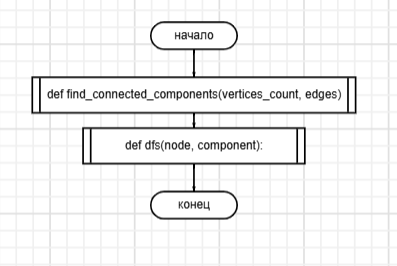

**def find_connected_components(vertices_count, edges)**

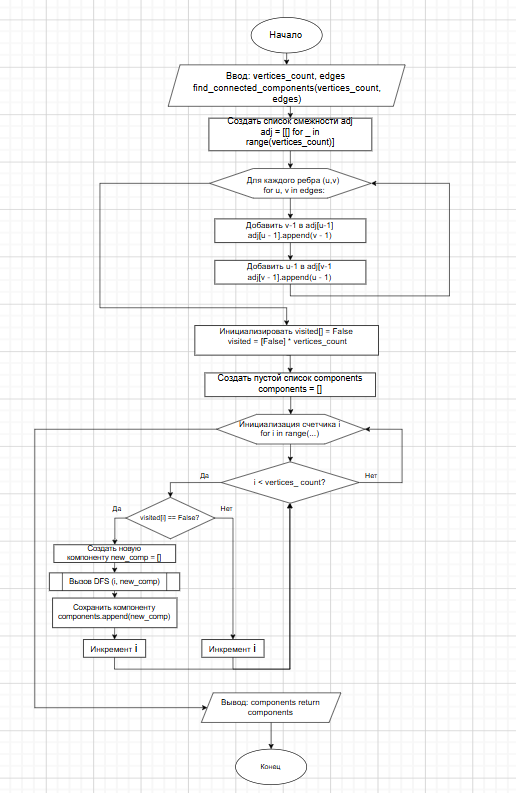

**def dfs(node, component):**

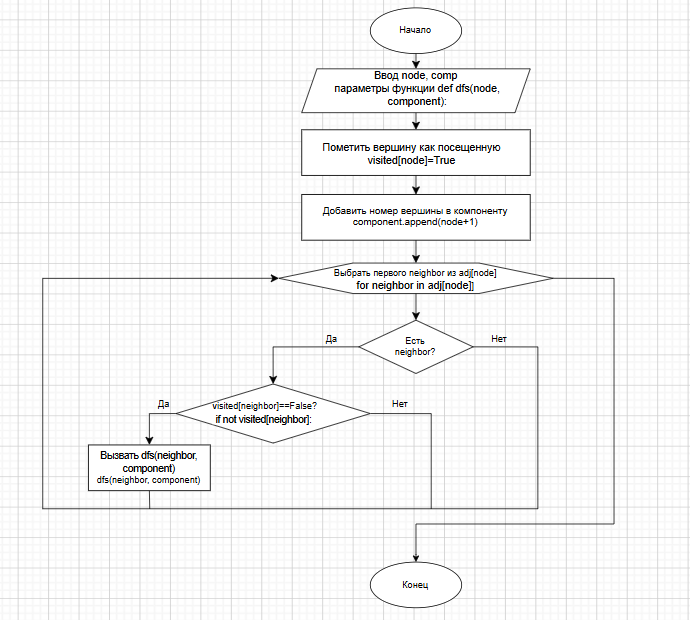

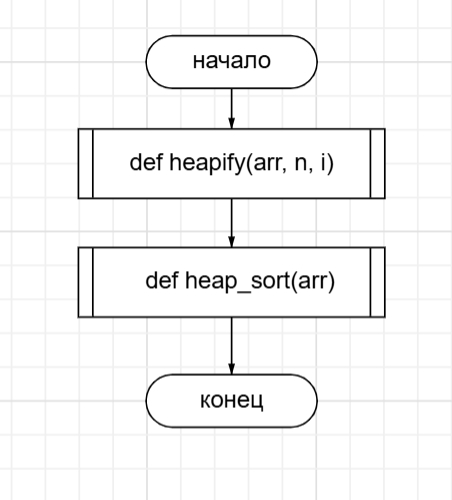

**def heap_sort(arr)**

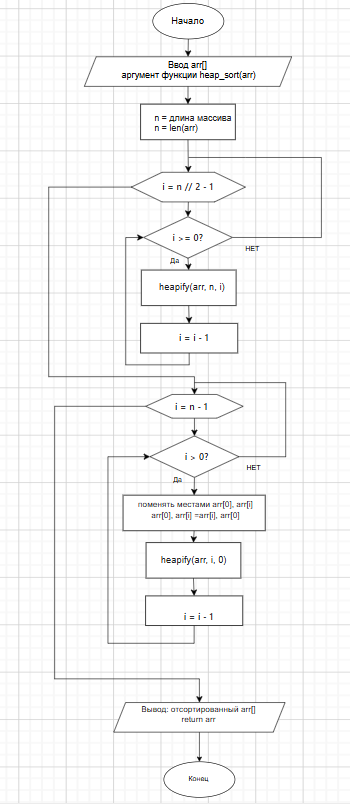

**def heapify(arr, n, i)**

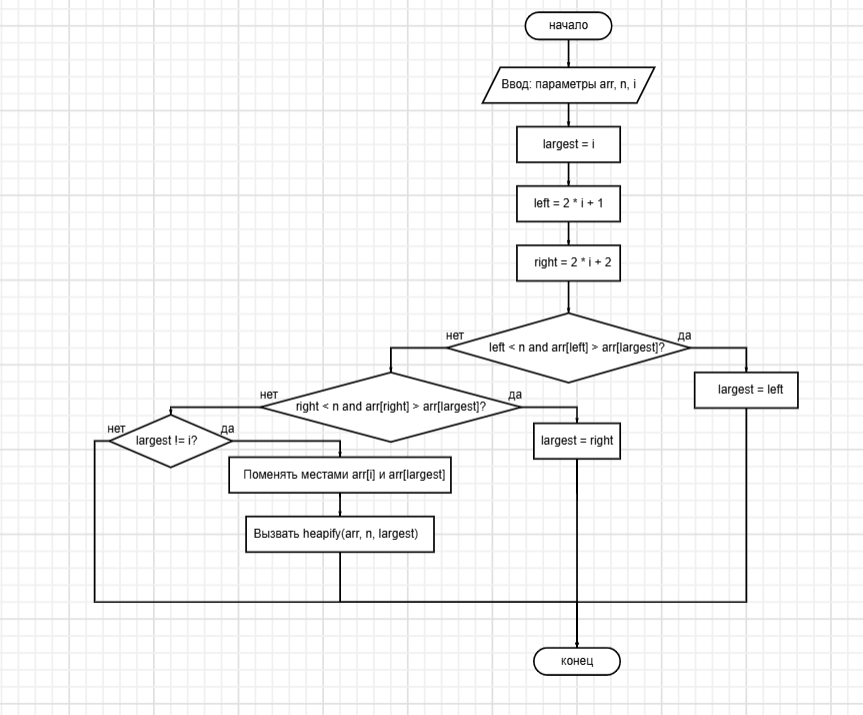